In [1]:
import pandas as pd


#load dataset (reolace with your actual path)
df=pd.read_csv("/content/HR_Job_Placement_Dataset.csv")

#display basic summary statics
print(df.describe())

          age_years  ssc_percentage  hsc_percentage  degree_percentage  \
count  51500.000000    48919.000000    49435.000000       51500.000000   
mean      27.505456       70.002505       72.060636          74.010825   
std        4.025385        7.976314        7.916654           6.945579   
min       21.000000       50.000000       50.000000          55.000000   
25%       24.000000       64.574733       66.720058          69.305041   
50%       27.000000       69.971210       72.014383          73.998187   
75%       31.000000       75.389057       77.389894          78.707827   
max       34.000000       95.000000       95.000000          95.000000   

       technical_score  aptitude_score  communication_score  \
count     51500.000000    51500.000000         51500.000000   
mean         68.027499       64.005715            66.106692   
std          11.855145        9.922397             9.907488   
min          40.000000       40.000000            45.000000   
25%          59.93

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [4]:
# Handling missing values for ssc_percentage,hsc_percentage,career_switch_willingness,relevant_experience,job_role_match,
#notice_period_days,layoff_history,employment_gap_months,relocation_willingness

print(df.dtypes)

age_years                      int64
gender                        object
ssc_percentage               float64
hsc_percentage               float64
degree_percentage            float64
degree_specialization         object
technical_score              float64
aptitude_score               float64
communication_score          float64
skills_match_percentage      float64
certifications_count           int64
internship_experience         object
years_of_experience            int64
career_switch_willingness     object
relevant_experience           object
previous_ctc_lpa             float64
expected_ctc_lpa             float64
company_tier                  object
job_role_match                object
competition_level             object
bond_requirement              object
notice_period_days           float64
layoff_history                object
employment_gap_months        float64
relocation_willingness        object
status                        object
dtype: object


In [5]:
#Seperating the numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

Numerical columns: Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months'],
      dtype='object')
Categorical columns: Index(['gender', 'degree_specialization', 'internship_experience',
       'career_switch_willingness', 'relevant_experience', 'company_tier',
       'job_role_match', 'competition_level', 'bond_requirement',
       'layoff_history', 'relocation_willingness', 'status'],
      dtype='object')


**Handling missing values using mean, median, or mode**

In [6]:
#Step 1: Before handling missing values

df.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,2581
hsc_percentage,2065
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [7]:
#Handling missing values for  numerical and categorical columns


# Numerical → mean / median
df['ssc_percentage'] = df['ssc_percentage'].fillna(df['ssc_percentage'].mean())
df['hsc_percentage'] = df['hsc_percentage'].fillna(df['hsc_percentage'].mean())
df['notice_period_days'] = df['notice_period_days'].fillna(df['notice_period_days'].median())
df['employment_gap_months'] = df['employment_gap_months'].fillna(df['employment_gap_months'].median())

# Categorical → mode
cat_cols = [
    'career_switch_willingness',
    'relevant_experience',
    'job_role_match',
    'layoff_history',
    'relocation_willingness']

for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

# 🔹 step 2: AFTER handling missing values
print("\nAfter Handling Missing Values:\n")
print(df.isnull().sum())

# -------------------------------------
# 🔹 Sample Data
print("\nSample Data:\n")
print(df.head())



After Handling Missing Values:

age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64

Sample Data:

   age_years  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0         27    Male       65.061656       83.842578      

**Encoding categorical variables (Label / One-Hot Encoding)**

In [8]:
# ==========================================
# 🔥Encoding
# ==========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = df.copy()
#to remove warning
pd.set_option('future.no_silent_downcasting', True)


# ------------------------------------------
# 🔹 Step 0: Replace infinite values
# ------------------------------------------
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# ------------------------------------------
# 🔹 Step 1: Clean all text columns
# ------------------------------------------
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# ------------------------------------------
# 🔹 Step 2: SAFE Binary Encoding (VERY IMPORTANT)
# ------------------------------------------
binary_cols = [
    'internship_experience',
    'career_switch_willingness',
    'relevant_experience'
]

for col in binary_cols:
    df[col] = df[col].replace({
        'yes': 1, 'no': 0,
        'willing': 1, 'not willing': 0,
        'true': 1, 'false': 0
    })

    # Convert non-mapped values to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill safely
    df[col] = df[col].fillna(0).astype(int)

# ------------------------------------------
# 🔹 Step 3: Special Columns Fix
# ------------------------------------------
special_cols = {
    'bond_requirement': {'required':1, 'not required':0},
    'relocation_willingness': {'willing':1, 'not willing':0}
}

for col, mapping in special_cols.items():
    df[col] = df[col].replace(mapping)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0).astype(int)

# ------------------------------------------
# 🔹 Step 4: Handle Remaining Missing Values
# ------------------------------------------
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# ------------------------------------------
# 🔹 Step 5: Label Encoding
# ------------------------------------------
le = LabelEncoder()

for col in ['competition_level', 'company_tier']:
    df[col] = le.fit_transform(df[col])

# ------------------------------------------
# 🔹 Step 6: One-Hot Encoding
# ------------------------------------------
cols_to_encode = ['gender', 'degree_specialization', 'job_role_match']

existing_cols = [col for col in cols_to_encode if col in df.columns]

if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

# ------------------------------------------
# 🔹 Step 7: SAFE Target Encoding
# ------------------------------------------
df['status'] = df['status'].replace({
    'placed': 1,
    'not placed': 0,
    'notplaced': 0,
    'not_placed': 0
})

df['status'] = pd.to_numeric(df['status'], errors='coerce')
df['status'] = df['status'].fillna(0).astype(int)

# ------------------------------------------
# 🔹 Step 8: Final Check
# ------------------------------------------
print("✅ Missing Values:\n", df.isnull().sum())

print("\n✅ Status Distribution:\n", df['status'].value_counts())

print("\n✅ Dataset Shape:", df.shape)

print("\n✅ Sample Data:\n", df.head())

✅ Missing Values:
 age_years                                       0
ssc_percentage                                  0
hsc_percentage                                  0
degree_percentage                               0
technical_score                                 0
aptitude_score                                  0
communication_score                             0
skills_match_percentage                         0
certifications_count                            0
internship_experience                           0
years_of_experience                             0
career_switch_willingness                       0
relevant_experience                             0
previous_ctc_lpa                                0
expected_ctc_lpa                                0
company_tier                                    0
competition_level                               0
bond_requirement                                0
notice_period_days                              0
layoff_history                 

**Feature scaling for numerical columns**

In [9]:
# ==========================================
# 🔹 FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler
import numpy as np

# ------------------------------------------
# 🔹 Step 1: Copy dataset
# ------------------------------------------
df_scaled = df.copy()

# ------------------------------------------
# 🔹 Step 2: Select Numerical Columns
# ------------------------------------------
num_cols = df_scaled.select_dtypes(include=['int64', 'float64']).columns

# ❗ Remove target column
if 'status' in num_cols:
    num_cols = num_cols.drop('status')

# ------------------------------------------
# 🔹 Step 3: Remove constant columns
# ------------------------------------------
num_cols = [col for col in num_cols if df_scaled[col].nunique() > 1]

# ------------------------------------------
# 🔹 Step 4: Apply Scaling
# ------------------------------------------
scaler = StandardScaler()

df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

# ------------------------------------------
# 🔹 Step 5: Verification
# ------------------------------------------
print("✅ Scaled Columns:\n", num_cols)

print("\n✅ Mean after scaling:\n")
print(df_scaled[num_cols].mean().round(2))

print("\n✅ Std after scaling:\n")
print(df_scaled[num_cols].std().round(2))

print("\n✅ Sample Data:\n")
print(df_scaled.head())

✅ Scaled Columns:
 ['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'technical_score', 'aptitude_score', 'communication_score', 'skills_match_percentage', 'certifications_count', 'internship_experience', 'years_of_experience', 'career_switch_willingness', 'previous_ctc_lpa', 'expected_ctc_lpa', 'company_tier', 'competition_level', 'bond_requirement', 'notice_period_days', 'employment_gap_months', 'relocation_willingness']

✅ Mean after scaling:

age_years                   -0.0
ssc_percentage               0.0
hsc_percentage               0.0
degree_percentage            0.0
technical_score              0.0
aptitude_score              -0.0
communication_score         -0.0
skills_match_percentage     -0.0
certifications_count        -0.0
internship_experience        0.0
years_of_experience         -0.0
career_switch_willingness    0.0
previous_ctc_lpa            -0.0
expected_ctc_lpa             0.0
company_tier                -0.0
competition_level            0.0


**Ensure Logical Consistency**

In [10]:
# ==========================================
# 🔹 ENSURE LOGICAL CONSISTENCY
# ==========================================

import numpy as np

# ------------------------------------------
# 🔹 1. Experience vs Internship
# ------------------------------------------
if 'years_of_experience' in df.columns and 'internship_experience' in df.columns:
    df.loc[df['years_of_experience'] > 0, 'internship_experience'] = 1

# ------------------------------------------
# 🔹 2. Experience vs Relevant Experience
# ------------------------------------------
if 'years_of_experience' in df.columns and 'relevant_experience' in df.columns:
    df.loc[df['years_of_experience'] > 0, 'relevant_experience'] = 1

# ------------------------------------------
# 🔹 3. Freshers → No Previous CTC
# ------------------------------------------
if 'years_of_experience' in df.columns and 'previous_ctc_lpa' in df.columns:
    df.loc[df['years_of_experience'] == 0, 'previous_ctc_lpa'] = 0

# ------------------------------------------
# 🔹 4. Expected CTC ≥ Previous CTC
# ------------------------------------------
if 'expected_ctc_lpa' in df.columns and 'previous_ctc_lpa' in df.columns:
    df['expected_ctc_lpa'] = np.where(
        df['expected_ctc_lpa'] < df['previous_ctc_lpa'],
        df['previous_ctc_lpa'],
        df['expected_ctc_lpa']
    )

# ------------------------------------------
# 🔹 5. Employment Gap only if experienced
# ------------------------------------------
if 'years_of_experience' in df.columns and 'employment_gap_months' in df.columns:
    df.loc[df['years_of_experience'] == 0, 'employment_gap_months'] = 0

# ------------------------------------------
# 🔹 6. Layoff History consistency
# ------------------------------------------
if 'layoff_history' in df.columns:
    df['layoff_history'] = df['layoff_history'].replace({'yes': 1, 'no': 0})
    df['layoff_history'] = df['layoff_history'].fillna(0).astype(int)

# ------------------------------------------
# 🔹 7. Scores must be within 0–100
# ------------------------------------------
score_cols = [
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_match_percentage'
]

for col in score_cols:
    if col in df.columns:
        df[col] = df[col].clip(0, 100)

# ------------------------------------------
# 🔹 8. Percentages must be within 0–100
# ------------------------------------------
perc_cols = [
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage'
]

for col in perc_cols:
    if col in df.columns:
        df[col] = df[col].clip(0, 100)

# ------------------------------------------
# 🔹 9. Age consistency
# ------------------------------------------
if 'age_years' in df.columns:
    df['age_years'] = df['age_years'].clip(16, 60)

# ------------------------------------------
# 🔹 10. Notice period cannot be negative
# ------------------------------------------
if 'notice_period_days' in df.columns:
    df['notice_period_days'] = df['notice_period_days'].clip(lower=0)

# ------------------------------------------
# 🔹 FINAL CHECK
# ------------------------------------------
print("✅ Logical consistency applied successfully!")

print("\nSample Data:\n")
print(df.head())

✅ Logical consistency applied successfully!

Sample Data:

   age_years  ssc_percentage  hsc_percentage  degree_percentage  \
0         27       65.061656       83.842578          75.856526   
1         24       67.885626       64.973305          73.093588   
2         33       73.892471       68.834121          90.196460   
3         31       74.145568       76.255126          75.586731   
4         28       60.475937       65.786336          80.801010   

   technical_score  aptitude_score  communication_score  \
0        58.221909       89.566305            64.474484   
1        71.927978       54.591971            61.077306   
2        72.445041       58.587088            79.494739   
3        78.855676       61.022065            53.740386   
4        68.286776       65.713731            61.438314   

   skills_match_percentage  certifications_count  internship_experience  ...  \
0                79.548913                     2                      1  ...   
1                73.316

# **Exploratory Data Analysis (EDA)**


Interview score vs job acceptance

Unique Status Values: [0 1]

Sample Scores:

   avg_interview_score  status
0            70.754233       0
1            62.532418       0
2            70.175622       1
3            64.539376       0
4            65.146274       0

📊 Average Interview Score by Status:

status
0    64.694758
1    69.163701
Name: avg_interview_score, dtype: float64


<Figure size 640x480 with 0 Axes>

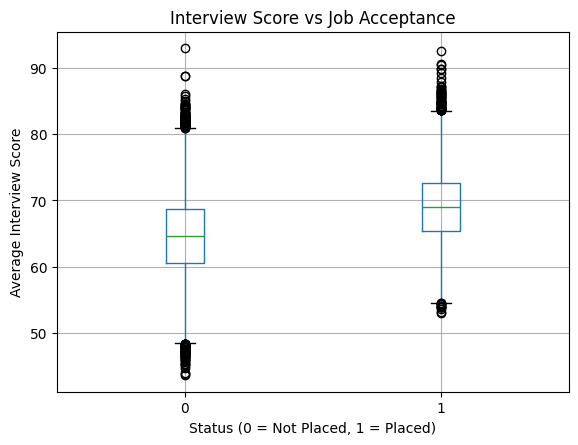

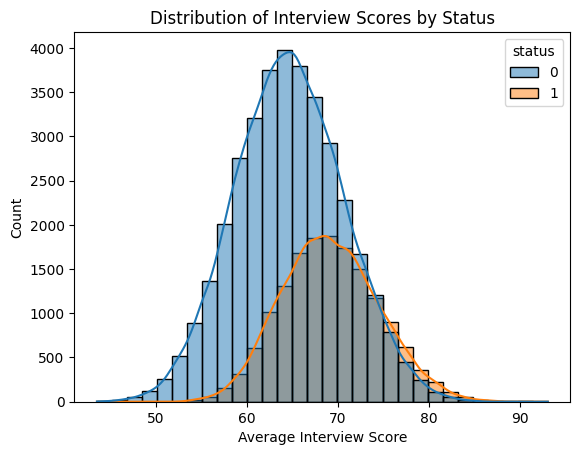


📈 Correlation between Interview Score & Placement: 0.336


In [11]:
# ==========================================
# 🔹 EDA: Interview Score vs Job Acceptance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Create Average Interview Score
# ------------------------------------------
score_cols = ['technical_score', 'aptitude_score', 'communication_score']

# Ensure columns exist
score_cols = [col for col in score_cols if col in df_eda.columns]

df_eda['avg_interview_score'] = df_eda[score_cols].mean(axis=1)

# ------------------------------------------
# 🔹 Step 2: Check data availability
# ------------------------------------------
print("Unique Status Values:", df_eda['status'].unique())

print("\nSample Scores:\n")
print(df_eda[['avg_interview_score', 'status']].head())

# ------------------------------------------
# 🔹 Step 3: Group Analysis
# ------------------------------------------
group_avg = df_eda.groupby('status')['avg_interview_score'].mean()

print("\n📊 Average Interview Score by Status:\n")
print(group_avg)

# ------------------------------------------
# 🔹 Step 4: Visualization - Boxplot
# ------------------------------------------
plt.figure()
df_eda.boxplot(column='avg_interview_score', by='status')
plt.title('Interview Score vs Job Acceptance')
plt.suptitle('')
plt.xlabel('Status (0 = Not Placed, 1 = Placed)')
plt.ylabel('Average Interview Score')
plt.show()

# ------------------------------------------
# 🔹 Step 5: Distribution Plot
# ------------------------------------------
plt.figure()
sns.histplot(data=df_eda, x='avg_interview_score', hue='status', bins=30, kde=True)
plt.title('Distribution of Interview Scores by Status')
plt.xlabel('Average Interview Score')
plt.ylabel('Count')
plt.show()

# ------------------------------------------
# 🔹 Step 6: Correlation
# ------------------------------------------
correlation = df_eda['avg_interview_score'].corr(df_eda['status'])

print("\n📈 Correlation between Interview Score & Placement:", round(correlation, 3))

Skills match percentage impact on placement

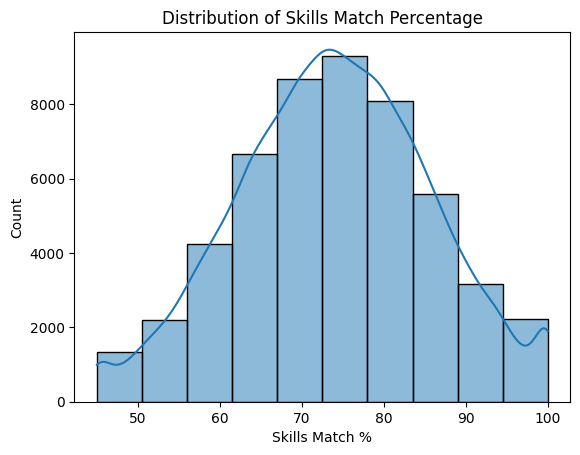

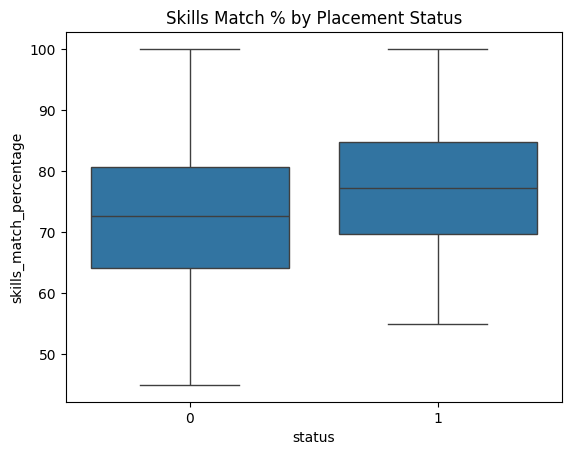

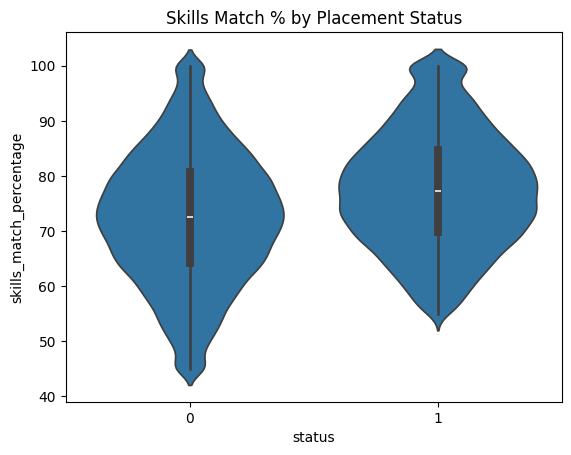

In [12]:
import pandas as pd


#Step 1: Summary stats
df['skills_match_percentage'].describe()
df['status'].value_counts(normalize=True) * 100  # Placement distribution

#Step 2:Distribution of Skills Match %
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['skills_match_percentage'], bins=10, kde=True)
plt.title('Distribution of Skills Match Percentage')
plt.xlabel('Skills Match %')
plt.ylabel('Count')
plt.show()

#Step 3:Compare Skills Match by Placement
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title('Skills Match % by Placement Status')
plt.show()

sns.violinplot(x='status', y='skills_match_percentage', data=df)
plt.title('Skills Match % by Placement Status')
plt.show()

skills_bin
0-50       0.000000
51-60     13.529638
61-70     26.297771
71-80     32.009374
81-90     37.289194
91-100    44.053708
Name: status, dtype: float64


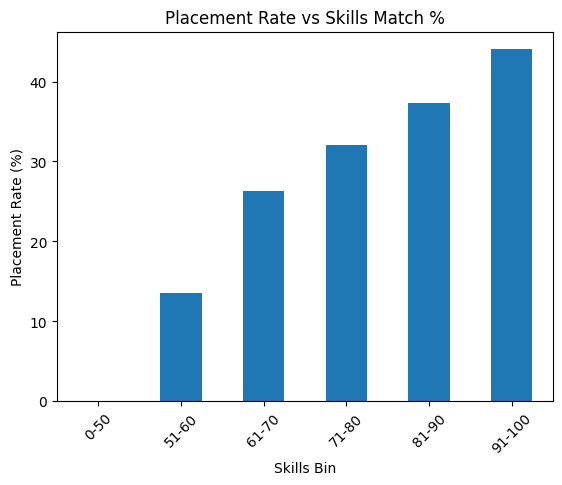

In [13]:
#Step 4:Placement Rate vs Skills Match Bins

# Bin skills match %
bins = [0,50,60,70,80,90,100]
labels = ['0-50','51-60','61-70','71-80','81-90','91-100']
df['skills_bin'] = pd.cut(df['skills_match_percentage'], bins=bins, labels=labels)

# Placement rate per bin
# Convert to string first
df['status'] = df['status'].astype(str)
placement_rate= df.groupby('skills_bin',observed=False)['status'].apply(lambda x: (x == '1').mean() * 100)

print(placement_rate)

# Plot
plt.figure()

placement_rate.plot(kind='bar')

plt.title("Placement Rate vs Skills Match %")
plt.xlabel("Skills Bin")
plt.ylabel("Placement Rate (%)")

plt.xticks(rotation=45)
plt.show()

**Company tier vs acceptance rate**


📊 Acceptance Rate by Company Tier:

company_tier
0    29.947681
1    30.452351
2    30.423365
Name: status, dtype: float64


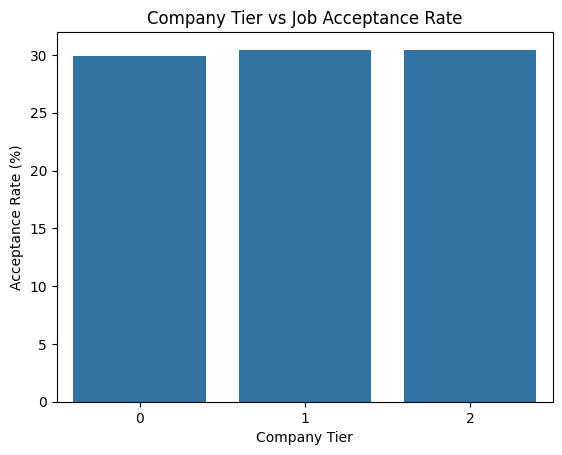

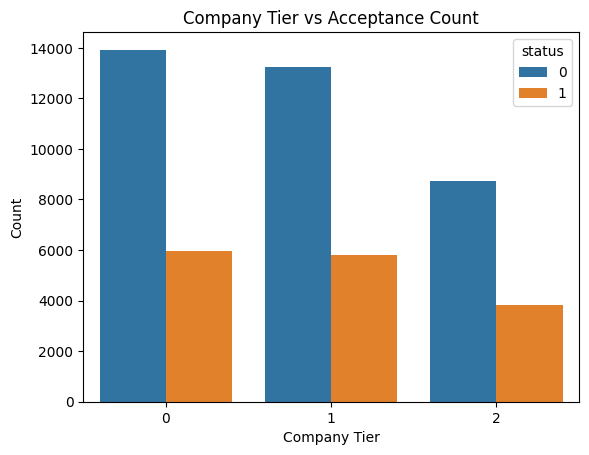


📈 Average Acceptance (0–1 scale):

company_tier
0    0.299477
1    0.304524
2    0.304234
Name: status, dtype: float64


In [14]:
df_eda = df.copy()

# Handle missing values
df_eda['company_tier'] = df_eda['company_tier'].fillna('Unknown')
df_eda['status'] = df_eda['status'].fillna(0).astype(int)

#Step 1:Acceptance Rate Calculation
acceptance_rate = df_eda.groupby('company_tier', observed=False)['status'].mean() * 100

print("\n📊 Acceptance Rate by Company Tier:\n")
print(acceptance_rate)

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.barplot(x=acceptance_rate.index, y=acceptance_rate.values)

plt.title("Company Tier vs Job Acceptance Rate")
plt.xlabel("Company Tier")
plt.ylabel("Acceptance Rate (%)")

plt.show()

#Count Plot (Distribution)

plt.figure()

sns.countplot(x='company_tier', hue='status', data=df_eda)

plt.title("Company Tier vs Acceptance Count")
plt.xlabel("Company Tier")
plt.ylabel("Count")

plt.show()

avg_status = df_eda.groupby('company_tier')['status'].mean()

print("\n📈 Average Acceptance (0–1 scale):\n")
print(avg_status)

**Experience vs placement probability**


📊 Placement % by Experience Level:

experience_level
Fresher      13.792208
Junior       29.153566
Mid-Level    53.722334
Name: status, dtype: float64


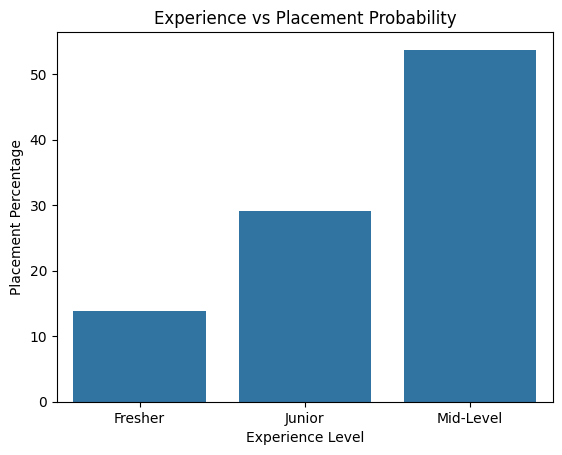


📈 Correlation between Experience & Placement: 0.331


In [15]:
#Create Experience Categories

def exp_category(x):
    if x == 0:
        return 'Fresher'
    elif x <= 2:
        return 'Junior'
    elif x <= 5:
        return 'Mid-Level'
    else:
        return 'Senior'

df_eda['experience_level'] = df_eda['years_of_experience'].apply(exp_category)

#Step 2:Placement Probability

placement_rate = df_eda.groupby('experience_level', observed=False)['status'].mean() * 100

print("\n📊 Placement % by Experience Level:\n")
print(placement_rate)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.barplot(x=placement_rate.index, y=placement_rate.values)

plt.title("Experience vs Placement Probability")
plt.xlabel("Experience Level")
plt.ylabel("Placement Percentage")

plt.show()

#correlation
correlation = df_eda['years_of_experience'].corr(df_eda['status'])

print("\n📈 Correlation between Experience & Placement:", round(correlation, 3))

**Competition level vs job acceptance**


📊 Competition Category Count:

competition_category
Medium    21414
High      19708
Low       10378
Name: count, dtype: int64

📊 Acceptance Rate by Competition Level:

competition_category
High      31.895677
Low       23.790711
Medium    31.867003
Name: status, dtype: float64


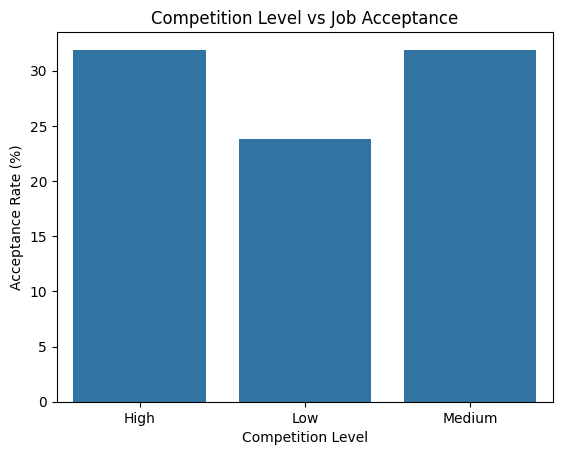

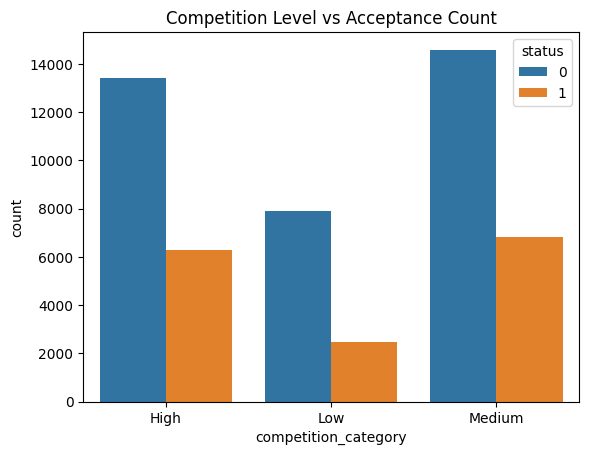

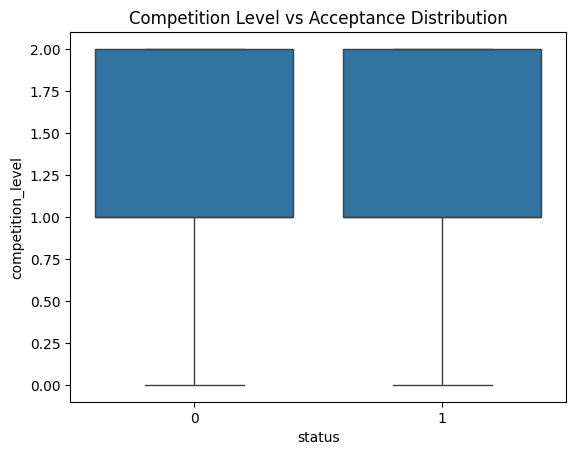

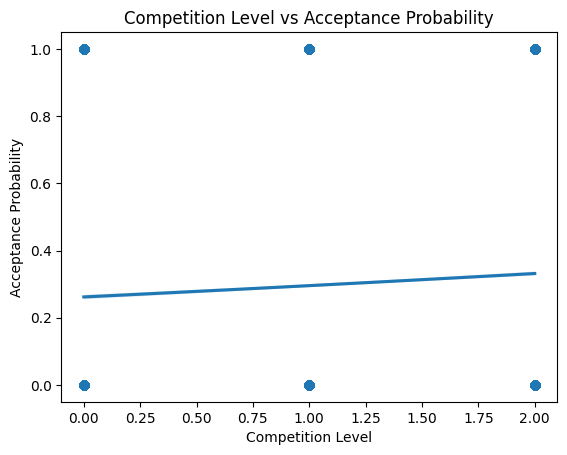


📈 Correlation: 0.057


In [16]:
# ==========================================
# 🔹 EDA: Competition Level vs Job Acceptance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Data Cleaning
# ------------------------------------------
df_eda['status'] = df_eda['status'].fillna(0).astype(int)

# ------------------------------------------
# 🔹 Step 2: Map Competition Levels (FIX)
# ------------------------------------------
# Since values are 0,1,2 → map directly

mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

df_eda['competition_category'] = df_eda['competition_level'].map(mapping)

# Check distribution
print("\n📊 Competition Category Count:\n")
print(df_eda['competition_category'].value_counts())

# ------------------------------------------
# 🔹 Step 3: Acceptance Rate Calculation
# ------------------------------------------
acceptance_rate = df_eda.groupby('competition_category', observed=False)['status'].mean() * 100

print("\n📊 Acceptance Rate by Competition Level:\n")
print(acceptance_rate)

# ------------------------------------------
# 🔹 Step 4: Bar Plot
# ------------------------------------------
plt.figure()

sns.barplot(x=acceptance_rate.index, y=acceptance_rate.values)

plt.title("Competition Level vs Job Acceptance")
plt.xlabel("Competition Level")
plt.ylabel("Acceptance Rate (%)")

plt.show()

# ------------------------------------------
# 🔹 Step 5: Count Plot
# ------------------------------------------
plt.figure()

sns.countplot(x='competition_category', hue='status', data=df_eda)

plt.title("Competition Level vs Acceptance Count")
plt.show()

# ------------------------------------------
# 🔹 Step 6: Box Plot
# ------------------------------------------
plt.figure()

sns.boxplot(x='status', y='competition_level', data=df_eda)

plt.title("Competition Level vs Acceptance Distribution")
plt.show()

# ------------------------------------------
# 🔹 Step 7: Regression Plot ⭐ (BEST)
# ------------------------------------------
plt.figure()

sns.regplot(x='competition_level', y='status', data=df_eda, logistic=True)

plt.title("Competition Level vs Acceptance Probability")
plt.xlabel("Competition Level")
plt.ylabel("Acceptance Probability")

plt.show()

# ------------------------------------------
# 🔹 Step 8: Correlation
# ------------------------------------------
corr = df_eda['competition_level'].corr(df_eda['status'])
print("\n📈 Correlation:", round(corr, 3))

**Correlation analysis among numeric features**

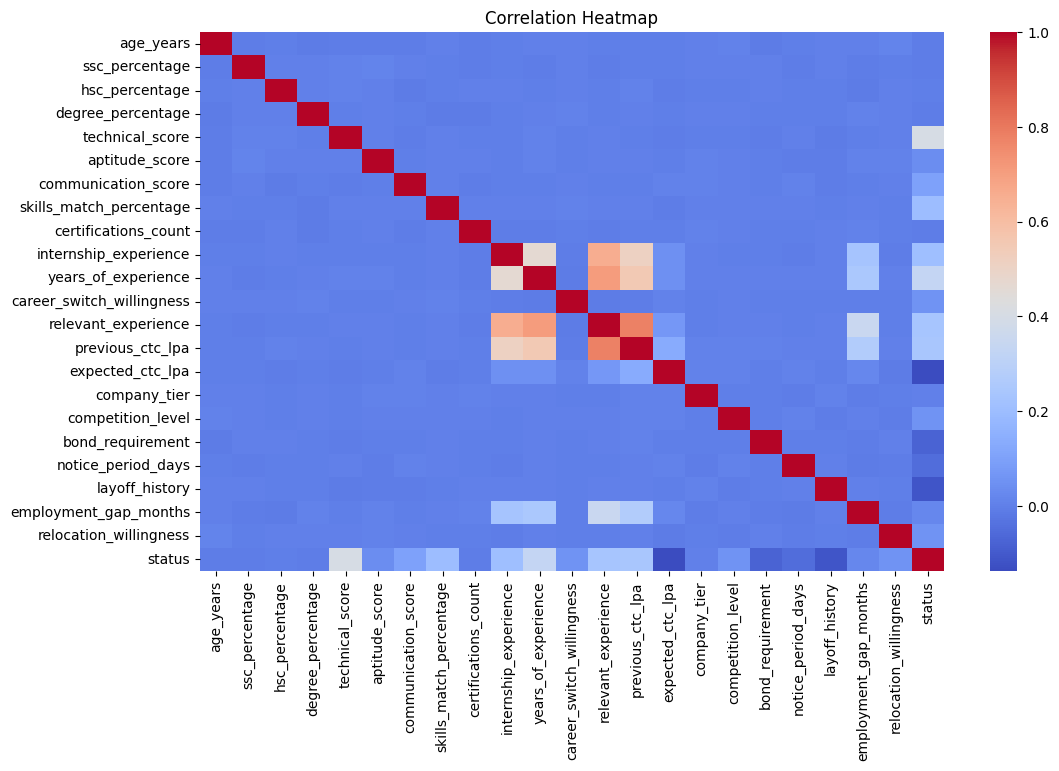


🎯 Correlation with Placement:

status                       1.000000
technical_score              0.404157
years_of_experience          0.331454
previous_ctc_lpa             0.240198
relevant_experience          0.234021
internship_experience        0.209101
skills_match_percentage      0.197855
communication_score          0.098758
competition_level            0.056623
relocation_willingness       0.056016
career_switch_willingness    0.055863
aptitude_score               0.039164
employment_gap_months        0.018795
company_tier                 0.004434
hsc_percentage              -0.002143
ssc_percentage              -0.004253
age_years                   -0.005004
certifications_count        -0.005165
degree_percentage           -0.007571
notice_period_days          -0.050595
bond_requirement            -0.076778
layoff_history              -0.112647
expected_ctc_lpa            -0.136946
Name: status, dtype: float64


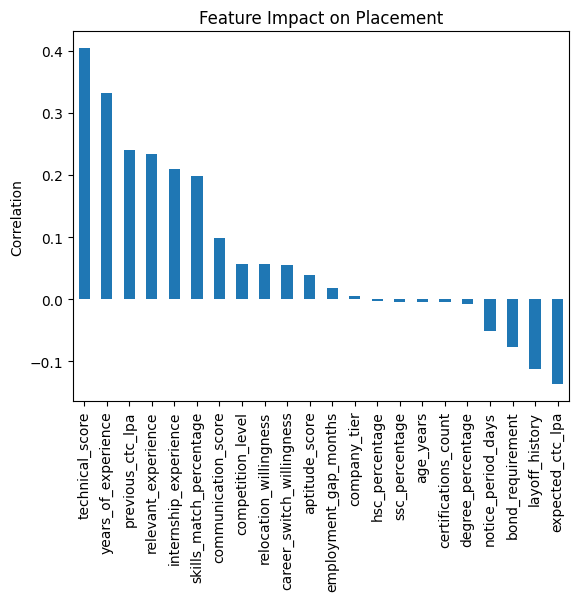

In [17]:
# ==========================================
# 🔹 EDA: Correlation Analysis (Numeric Features)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# Ensure status exists & is numeric
df_eda['status'] = df_eda['status'].astype(int)

# ------------------------------------------
# 🔹 Step 1: Select Numeric Columns
# ------------------------------------------
numeric_cols = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'status' not in numeric_cols:
    numeric_cols.append('status')

# ------------------------------------------
# 🔹 Step 2: Correlation Matrix
# ------------------------------------------
corr_matrix = df_eda[numeric_cols].corr()

# ------------------------------------------
# 🔹 Step 3: Heatmap
# ------------------------------------------
plt.figure(figsize=(12, 7))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------
# 🔹 Step 4: Target Correlation
# ------------------------------------------
target_corr = corr_matrix['status'].sort_values(ascending=False)

print("\n🎯 Correlation with Placement:\n")
print(target_corr)

# ------------------------------------------
# 🔹 Step 5: Bar Plot
# ------------------------------------------
plt.figure()

target_corr.drop('status').plot(kind='bar')

plt.title("Feature Impact on Placement")
plt.ylabel("Correlation")

plt.show()


# **Feature Engineering**


📊 Experience Category Count:

experience_category
Junior     24172
Fresher    15400
Senior     11928
Name: count, dtype: int64

📊 Placement % by Experience Category:

experience_category
Fresher    13.792208
Junior     29.153566
Senior     53.722334
Name: status, dtype: float64


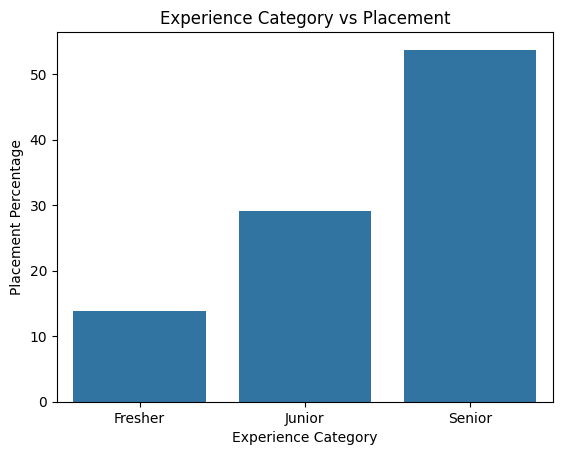

In [18]:
#Experience category (Fresher / Junior / Senior)
# 🔹 Feature Engineering: Experience Category
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Handle Missing Values
# ------------------------------------------
df_eda['years_of_experience'] = df_eda['years_of_experience'].fillna(0)

# ------------------------------------------
# 🔹 Step 2: Create Experience Categories
# ------------------------------------------
def exp_category(x):
    if x == 0:
        return 'Fresher'
    elif x <= 2:
        return 'Junior'
    else:
        return 'Senior'

df_eda['experience_category'] = df_eda['years_of_experience'].apply(exp_category)

# ------------------------------------------
# 🔹 Step 3: Check Distribution
# ------------------------------------------
print("\n📊 Experience Category Count:\n")
print(df_eda['experience_category'].value_counts())


# ------------------------------------------
# 🔹 Fix status datatype
# ------------------------------------------
df_eda['status'] = df_eda['status'].astype(int)

# ------------------------------------------
# 🔹 Step 4: Placement Analysis
# ------------------------------------------
placement_rate = df_eda.groupby('experience_category', observed=False)['status'].mean() * 100

print("\n📊 Placement % by Experience Category:\n")
print(placement_rate)


# ------------------------------------------
# 🔹 Step 5: Visualization
# ------------------------------------------
plt.figure()

sns.barplot(x=placement_rate.index, y=placement_rate.values)

plt.title("Experience Category vs Placement")
plt.xlabel("Experience Category")
plt.ylabel("Placement Percentage")

plt.show()


📊 Academic Band Count:

academic_band
High         34912
Medium       16516
Very High       72
Name: count, dtype: int64

📊 Placement % by Academic Band:

academic_band
High         30.092805
Medium       30.600630
Very High    26.388889
Name: status, dtype: float64


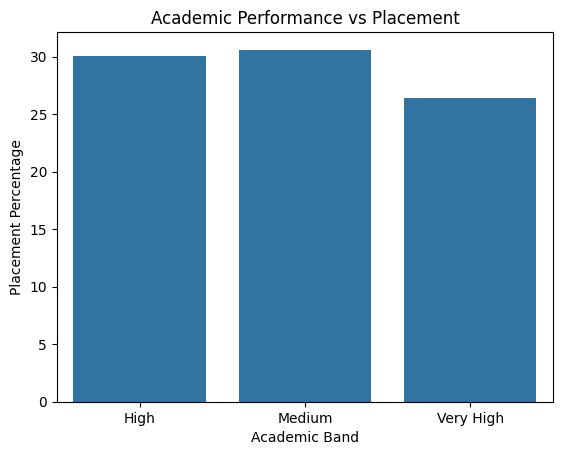

In [19]:
#Academic performance bands

# ==========================================
# 🔹 Feature Engineering: Academic Performance Bands
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Handle Missing Values
# ------------------------------------------
cols = ['ssc_percentage', 'hsc_percentage', 'degree_percentage']

for col in cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

# ------------------------------------------
# 🔹 Step 2: Create Average Academic Score
# ------------------------------------------
df_eda['avg_academic_score'] = df_eda[cols].mean(axis=1)

# ------------------------------------------
# 🔹 Step 3: Create Academic Bands
# ------------------------------------------
def academic_band(x):
    if x < 50:
        return 'Low'
    elif x < 70:
        return 'Medium'
    elif x < 85:
        return 'High'
    else:
        return 'Very High'

df_eda['academic_band'] = df_eda['avg_academic_score'].apply(academic_band)

# ------------------------------------------
# 🔹 Step 4: Check Distribution
# ------------------------------------------
print("\n📊 Academic Band Count:\n")
print(df_eda['academic_band'].value_counts())

# ------------------------------------------
# 🔹 Step 5: Placement Analysis
# ------------------------------------------
df_eda['status'] = df_eda['status'].astype(int)

placement_rate = df_eda.groupby('academic_band', observed=False)['status'].mean() * 100

print("\n📊 Placement % by Academic Band:\n")
print(placement_rate)

# ------------------------------------------
# 🔹 Step 6: Visualization
# ------------------------------------------
plt.figure()

sns.barplot(x=placement_rate.index, y=placement_rate.values)

plt.title("Academic Performance vs Placement")
plt.xlabel("Academic Band")
plt.ylabel("Placement Percentage")

plt.show()


📊 Skills Level Count:

skills_level
High      32541
Medium    18959
Name: count, dtype: int64

📊 Placement % by Skills Level:

skills_level
High      35.564365
Medium    21.129806
Name: status, dtype: float64


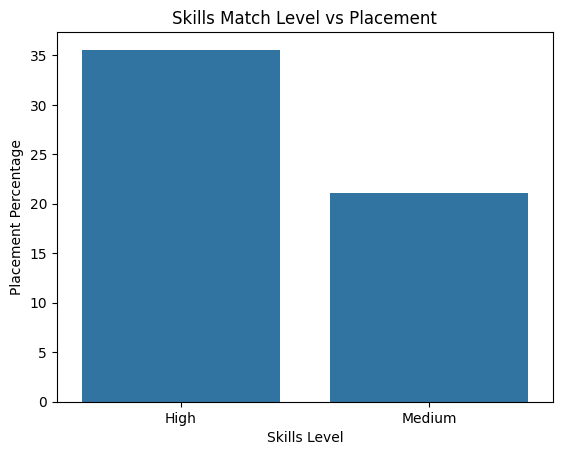

In [20]:
#Skills match level (Low / Medium / High)
# ==========================================
# 🔹 Feature Engineering: Skills Match Level
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Handle Missing Values
# ------------------------------------------
df_eda['skills_match_percentage'] = df_eda['skills_match_percentage'].fillna(
    df_eda['skills_match_percentage'].median()
)

# ------------------------------------------
# 🔹 Step 2: Create Skill Level Categories
# ------------------------------------------
def skill_level(x):
    if x < 40:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

df_eda['skills_level'] = df_eda['skills_match_percentage'].apply(skill_level)

# ------------------------------------------
# 🔹 Step 3: Check Distribution
# ------------------------------------------
print("\n📊 Skills Level Count:\n")
print(df_eda['skills_level'].value_counts())

# ------------------------------------------
# 🔹 Step 4: Placement Analysis
# ------------------------------------------
df_eda['status'] = df_eda['status'].astype(int)

placement_rate = df_eda.groupby('skills_level', observed=False)['status'].mean() * 100

print("\n📊 Placement % by Skills Level:\n")
print(placement_rate)

# ------------------------------------------
# 🔹 Step 5: Visualization (Bar Plot)
# ------------------------------------------
plt.figure()

sns.barplot(x=placement_rate.index, y=placement_rate.values)

plt.title("Skills Match Level vs Placement")
plt.xlabel("Skills Level")
plt.ylabel("Placement Percentage")

plt.show()




📊 Interview Performance Count:

interview_performance
Medium    38114
High      13386
Name: count, dtype: int64

📊 Placement % by Interview Performance:

interview_performance
High      49.611534
Medium    23.450701
Name: status, dtype: float64


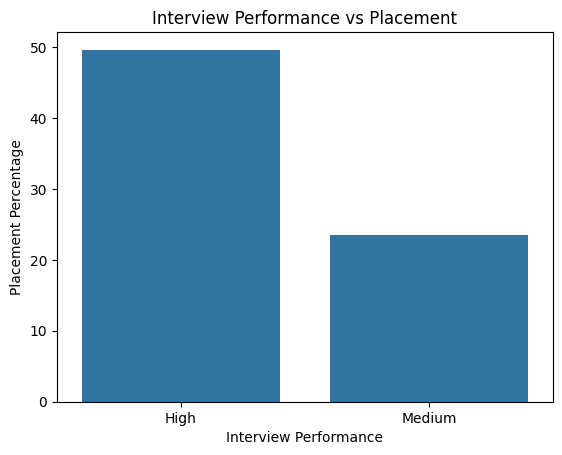

In [21]:
#Interview performance category

# ==========================================
# 🔹 Feature Engineering: Interview Performance Category
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Handle Missing Values
# ------------------------------------------
score_cols = ['technical_score', 'aptitude_score', 'communication_score']

for col in score_cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

# ------------------------------------------
# 🔹 Step 2: Create Average Interview Score
# ------------------------------------------
df_eda['avg_interview_score'] = df_eda[score_cols].mean(axis=1)

# ------------------------------------------
# 🔹 Step 3: Create Interview Categories
# ------------------------------------------
def interview_category(x):
    if x < 40:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

df_eda['interview_performance'] = df_eda['avg_interview_score'].apply(interview_category)

# ------------------------------------------
# 🔹 Step 4: Check Distribution
# ------------------------------------------
print("\n📊 Interview Performance Count:\n")
print(df_eda['interview_performance'].value_counts())

# ------------------------------------------
# 🔹 Step 5: Placement Analysis
# ------------------------------------------
df_eda['status'] = df_eda['status'].astype(int)

placement_rate = df_eda.groupby('interview_performance', observed=False)['status'].mean() * 100

print("\n📊 Placement % by Interview Performance:\n")
print(placement_rate)

# ------------------------------------------
# 🔹 Step 6: Visualization
# ------------------------------------------
plt.figure()

sns.barplot(x=placement_rate.index, y=placement_rate.values)

plt.title("Interview Performance vs Placement")
plt.xlabel("Interview Performance")
plt.ylabel("Placement Percentage")

plt.show()


📊 Placement Probability Score:

0    64.306427
1    54.717998
2    63.112282
3    56.447941
4    61.045243
Name: placement_probability_score, dtype: float64


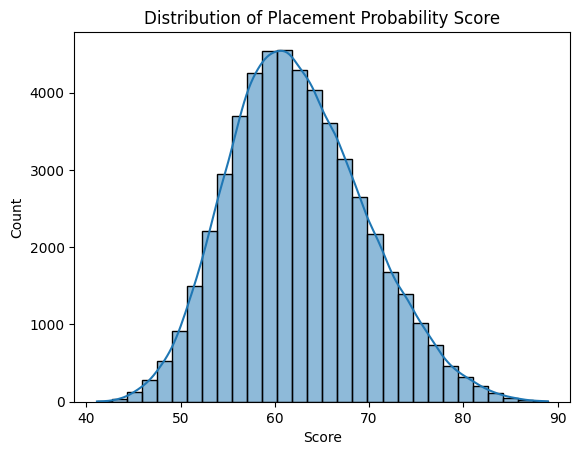

In [22]:
#Placement probability score

# ==========================================
# 🔹 Feature Engineering: Placement Probability Score
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

# ------------------------------------------
# 🔹 Step 1: Handle Missing Values
# ------------------------------------------
cols = ['skills_match_percentage', 'technical_score', 'aptitude_score',
        'communication_score', 'years_of_experience',
        'ssc_percentage', 'hsc_percentage', 'degree_percentage']

for col in cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

# ------------------------------------------
# 🔹 Step 2: Create Derived Features
# ------------------------------------------

# Interview Score
df_eda['avg_interview_score'] = df_eda[
    ['technical_score', 'aptitude_score', 'communication_score']
].mean(axis=1)

# Academic Score
df_eda['avg_academic_score'] = df_eda[
    ['ssc_percentage', 'hsc_percentage', 'degree_percentage']
].mean(axis=1)

# ------------------------------------------
# 🔹 Step 3: Normalize Experience (0–100)
# ------------------------------------------
max_exp = df_eda['years_of_experience'].max()

df_eda['exp_score'] = (df_eda['years_of_experience'] / max_exp) * 100

# ------------------------------------------
# 🔹 Step 4: Calculate Placement Probability Score
# ------------------------------------------
# Weighted formula (can explain in interview)

df_eda['placement_probability_score'] = (
    0.35 * df_eda['skills_match_percentage'] +
    0.30 * df_eda['avg_interview_score'] +
    0.20 * df_eda['exp_score'] +
    0.15 * df_eda['avg_academic_score']
)

# ------------------------------------------
# 🔹 Step 5: Check Output
# ------------------------------------------
print("\n📊 Placement Probability Score:\n")
print(df_eda['placement_probability_score'].head())

# ------------------------------------------
# 🔹 Step 6: Visualization
# ------------------------------------------
plt.figure()

sns.histplot(df_eda['placement_probability_score'], bins=30, kde=True)

plt.title("Distribution of Placement Probability Score")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()


In [29]:
df_ml.to_csv('cleaned_dataset.csv', index=False)

# **Machine Learning Modeling**


✅ Random Forest Accuracy: 0.872621359223301

📊 Confusion Matrix:
 [[6672  456]
 [ 856 2316]]

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      7128
           1       0.84      0.73      0.78      3172

    accuracy                           0.87     10300
   macro avg       0.86      0.83      0.84     10300
weighted avg       0.87      0.87      0.87     10300



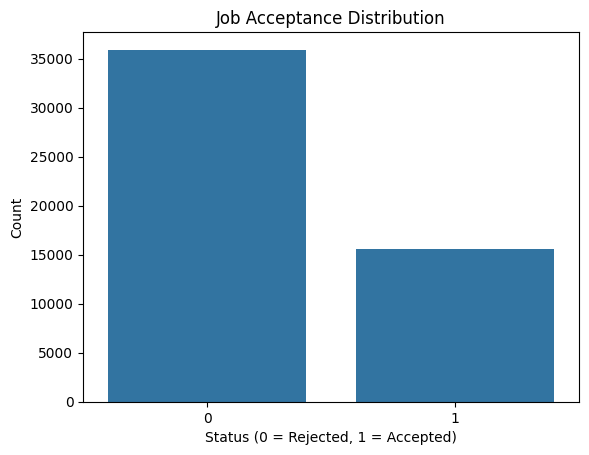

In [24]:
# ==========================================
# 🔹 ML MODEL
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_ml = df.copy()

# ------------------------------------------
# 🔹 Step 1: Target Variable
# ------------------------------------------
df_ml['status'] = df_ml['status'].astype(int)

# ------------------------------------------
# 🔹 Step 2: One-Hot Encoding (FIX)
# ------------------------------------------
df_ml = pd.get_dummies(df_ml, drop_first=True)

# ------------------------------------------
# 🔹 Step 3: Split Features & Target
# ------------------------------------------
X = df_ml.drop('status', axis=1)
y = df_ml['status']

# ------------------------------------------
# 🔹 Step 4: Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# 🔹 Step 5: Model
# ------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

# ------------------------------------------
# 🔹 Step 6: Prediction
# ------------------------------------------
y_pred_rf = rf.predict(X_test)

# ------------------------------------------
# 🔹 Step 7: Evaluation
# ------------------------------------------
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\n✅ Random Forest Accuracy:", rf_acc)

print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred_rf))


#visualization

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='status', data=df)

plt.title('Job Acceptance Distribution')
plt.xlabel('Status (0 = Rejected, 1 = Accepted)')
plt.ylabel('Count')

plt.show()

In [25]:
#feature importance
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\n🔥 Top Features:\n")
print(feature_importance.head(10))


🔥 Top Features:

technical_score            0.243097
years_of_experience        0.083485
skills_match_percentage    0.079525
expected_ctc_lpa           0.068929
previous_ctc_lpa           0.059366
communication_score        0.054435
aptitude_score             0.040129
degree_percentage          0.038601
ssc_percentage             0.038007
hsc_percentage             0.037731
dtype: float64


In [26]:
#Logistic regression model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8557281553398058


In [27]:
#Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_acc)


Gradient Boosting Accuracy: 0.873495145631068



===== MODEL PERFORMANCE =====
Accuracy: 0.8849514563106796

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92      7184
           1       0.78      0.86      0.82      3116

    accuracy                           0.88     10300
   macro avg       0.86      0.88      0.87     10300
weighted avg       0.89      0.88      0.89     10300


Confusion Matrix:
 [[6421  763]
 [ 422 2694]]


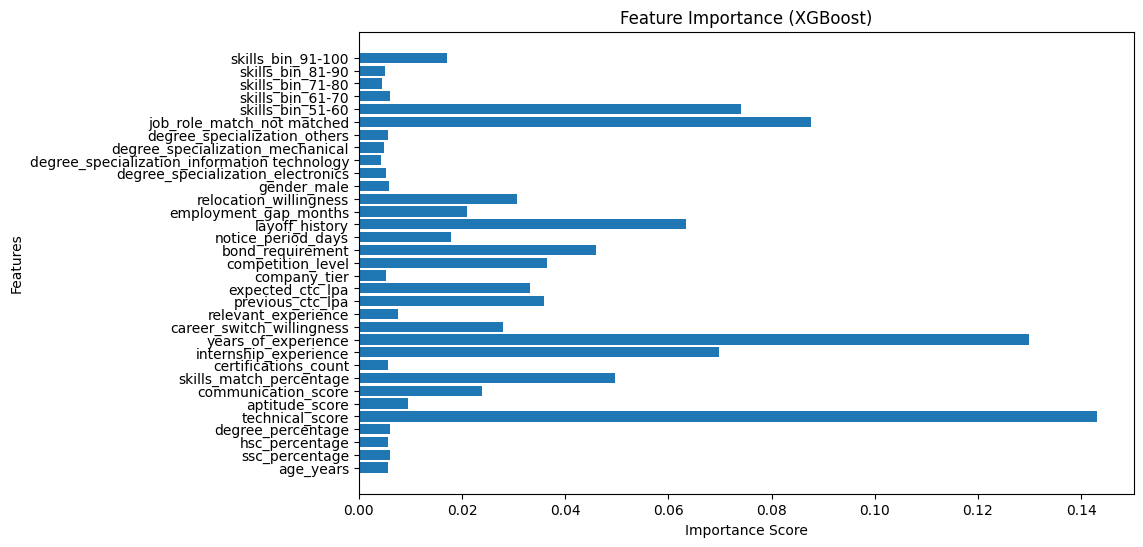

In [39]:
# ==============================
# XGBOOST COMPLETE PROGRAM
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
df = pd.read_csv("cleaned_dataset.csv")

# 3. Basic Preprocessing
# Convert categorical columns to numeric (if any)
df = pd.get_dummies(df, drop_first=True)

# 4. Define Features & Target
target_column ='status'   # Change based on your dataset

X = df.drop(target_column, axis=1)
y = df[target_column]

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 6. Model Initialization
model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=1.5,  # tuned instead of full ratio
    eval_metric='logloss'
)


# 7. Train Model
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)

# 9. Evaluation
print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

xgb_acc = accuracy_score(y_test, y_pred)

# 10. Feature Importance Visualization
plt.figure(figsize=(10,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [34]:
#Support vector machine

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)   # IMPORTANT: use scaled data
y_pred_svm = svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.87


In [40]:
#Comparing the model and accuracy


import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting','XGBoost', 'SVM'],
    'Accuracy': [ lr_acc, rf_acc,  gb_acc,xgb_acc, svm_acc]
})

print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
3              XGBoost  0.884951
2    Gradient Boosting  0.873495
1        Random Forest  0.872621
4                  SVM  0.870000
0  Logistic Regression  0.855728


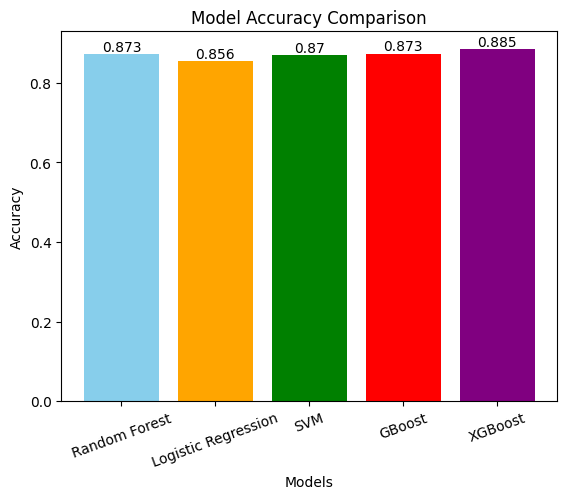

In [42]:
#Visualization of models

import matplotlib.pyplot as plt

models = ['Random Forest', 'Logistic Regression', 'SVM', 'GBoost','XGBoost']
accuracies = [rf_acc, lr_acc, svm_acc, gb_acc,xgb_acc]

# Different colors for each bar
colors = ['skyblue', 'orange', 'green', 'red','purple']

plt.figure()
bars = plt.bar(models, accuracies, color=colors)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3),
             ha='center', va='bottom')

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)

plt.show()

In [43]:
df.columns

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'competition_level',
       'bond_requirement', 'notice_period_days', 'layoff_history',
       'employment_gap_months', 'relocation_willingness', 'status',
       'gender_male', 'degree_specialization_electronics',
       'degree_specialization_information technology',
       'degree_specialization_mechanical', 'degree_specialization_others',
       'job_role_match_not matched', 'skills_bin_51-60', 'skills_bin_61-70',
       'skills_bin_71-80', 'skills_bin_81-90', 'skills_bin_91-100'],
      dtype='object')

# **Analyst Tasks (EDA & ML Analytics)**

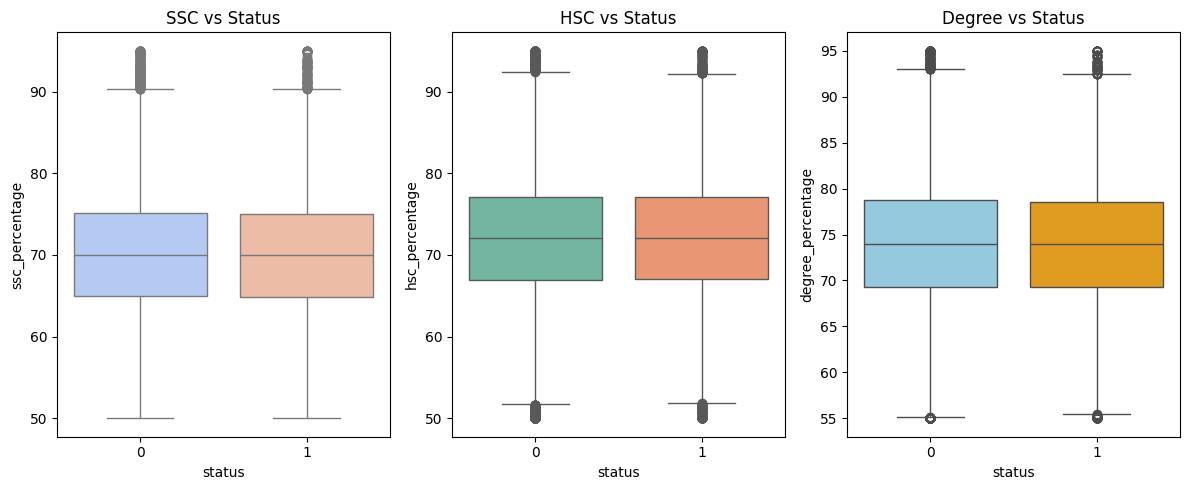

In [44]:
#Academic scores vs placement outcome

df['academic_score'] = df[['ssc_percentage', 'hsc_percentage', 'degree_percentage']].mean(axis=1)


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# 10th
plt.subplot(1,3,1)
sns.boxplot(x='status', y='ssc_percentage', data=df,hue='status',palette='coolwarm',legend=False)
plt.title('SSC vs Status')

# 12th
plt.subplot(1,3,2)
sns.boxplot(x='status', y='hsc_percentage', data=df,hue='status',palette='Set2',legend=False)
plt.title('HSC vs Status')

# Degree
plt.subplot(1,3,3)
sns.boxplot(x='status', y='degree_percentage', data=df,hue='status',palette=['skyblue', 'orange'],legend=False)
plt.title('Degree vs Status')

plt.tight_layout()
plt.show()

1.Candidates who accepted job offers generally have slightly higher academic scores compared to those who rejected.

**Improvement**:Focus on shortlisting candidates with strong academic performance, especially in higher education.

2.Degree percentage has a stronger impact than SSC and HSC scores, indicating that recent academic performance is more relevant.
**Improvement:**
Give higher weightage to degree performance during screening and evaluation

3.There is overlap between accepted and rejected candidates, showing that academic scores alone are not sufficient.
**Improvement:**
Incorporate additional factors like:
*  Skills match
*  Interview performance
*   Experience for better decision-making.

4.Academic performance is only one part of candidate evaluation.

**Improvement:**
Develop a multi-factor evaluation system combining:
*   Academic scores
*   Technical skills
*   Soft skills
*   Experience


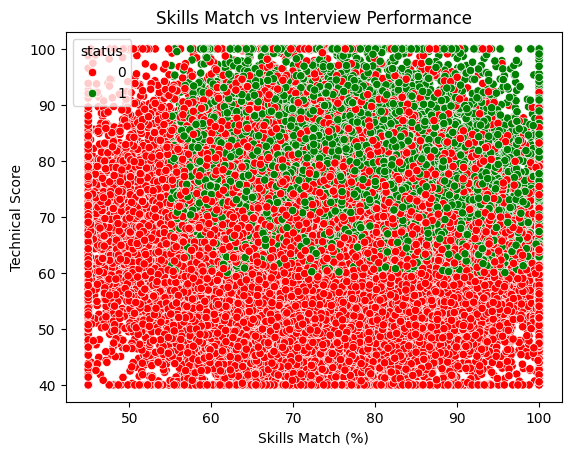

In [45]:
#Skills match vs interview performance

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.scatterplot(
    x='skills_match_percentage',
    y='technical_score',
    hue='status',
    data=df,
    palette=['red', 'green']
)

plt.title('Skills Match vs Interview Performance')
plt.xlabel('Skills Match (%)')
plt.ylabel('Technical Score')

plt.show()


*  1.Candidates with higher skills match tend to perform better in interviews.
*  2.A positive relationship exists between skill alignment and technical performance.
*   3.High skills match combined with strong interview scores increases job acceptance probability.
*   4.**Improvement**:Focus on improving candidate skill alignment through training and proper screening before interviews.







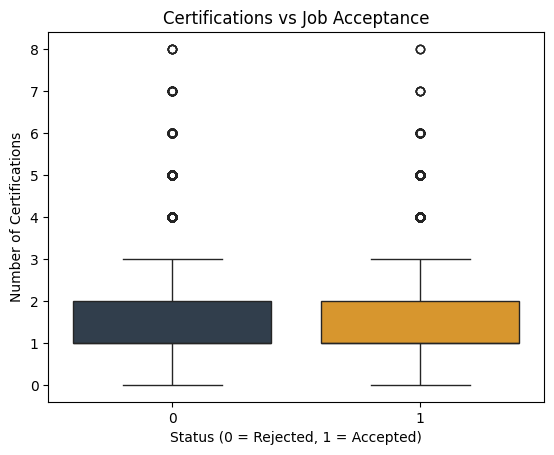

In [46]:
#Certification impact on job acceptance

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(
    x='status',
    y='certifications_count',
    data=df,
    hue='status',
    palette=['#2c3e50', '#f39c12'],
    legend=False
)

plt.title('Certifications vs Job Acceptance')
plt.xlabel('Status (0 = Rejected, 1 = Accepted)')
plt.ylabel('Number of Certifications')

plt.show()


*   Candidates with more certifications tend to have a higher job acceptance rate.
*  Certifications improve candidate credibility and increase selection chances.
*   However, overlap between groups shows that certifications alone are not sufficient.
*   Encourage candidates to pursue relevant certifications aligned with job roles.

*   Combine certifications with strong skills and interview performance for better outcomes.





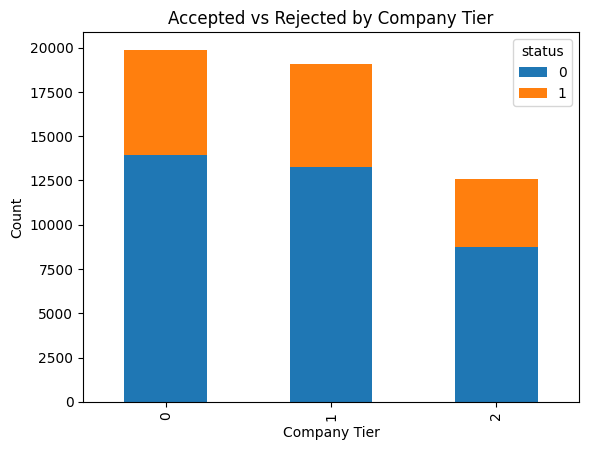

In [47]:
#Acceptance rate by company tier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tier_counts = pd.crosstab(df['company_tier'], df['status'])

tier_counts.plot(kind='bar', stacked=True)

plt.title('Accepted vs Rejected by Company Tier')
plt.xlabel('Company Tier')
plt.ylabel('Count')

plt.show()



*   Higher company tiers show a larger proportion of accepted candidates compared to rejected ones.
*  Lower company tiers have a relatively higher number of rejections, indicating lower candidate preference.
*   The difference between accepted and rejected candidates becomes more favorable as company tier increases
*   Lower-tier companies should enhance compensation, benefits, and career growth opportunities to improve acceptance rates.
Improving employer branding can help attract and retain candidate




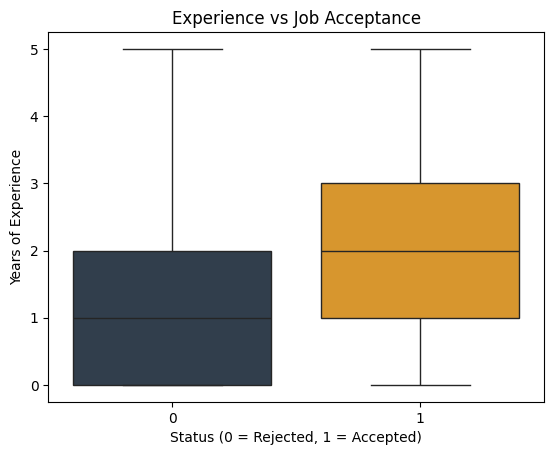

In [48]:
#Experience vs placement success

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(
    x='status',
    y='years_of_experience',
    data=df,
    hue='status',
    palette=['#2c3e50', '#f39c12'],
    legend=False
)

plt.title('Experience vs Job Acceptance')
plt.xlabel('Status (0 = Rejected, 1 = Accepted)')
plt.ylabel('Years of Experience')

plt.show()


*   Candidates with more experience tend to have higher job acceptance rates.
*   Experienced candidates are more likely to perform well and secure offers.
*   However, overlap indicates that freshers can also succeed with strong skills and performance.
*   Encourage candidates to gain relevant experience through internships and projects.
For freshers, focus on improving skills and certifications to increase placement chances.





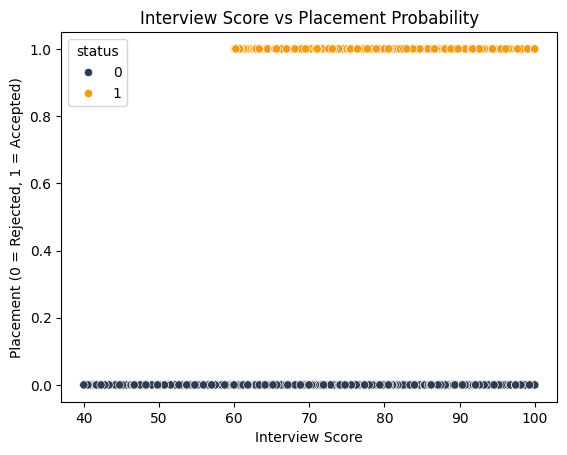

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.scatterplot(
    x='technical_score',
    y='status',
    data=df,
    hue='status',
    palette=['#2c3e50', '#f39c12']
)

plt.title('Interview Score vs Placement Probability')
plt.xlabel('Interview Score')
plt.ylabel('Placement (0 = Rejected, 1 = Accepted)')

plt.show()


*   Higher interview scores are strongly associated with higher placement probability.
*   Candidates with strong technical performance are more likely to get placed
*   Interview performance is one of the most influential factors in job acceptance.
*   Provide mock interviews and technical training to improve candidate performance.
Focus on strengthening problem-solving and communication skills during preparation.



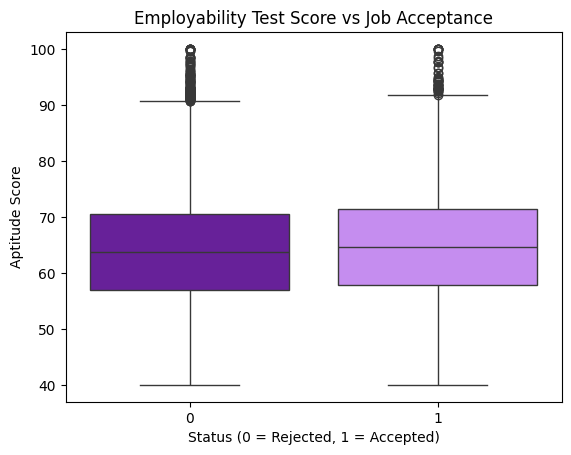

In [50]:
#Employability test score analysis

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(
    x='status',
    y='aptitude_score',
    data=df,
    hue='status',
    palette=['#6a0dad', '#c77dff'],
    legend=False
)

plt.title('Employability Test Score vs Job Acceptance')
plt.xlabel('Status (0 = Rejected, 1 = Accepted)')
plt.ylabel('Aptitude Score')

plt.show()



*  Candidates with higher employability (aptitude) scores are more likely to get place
*   A positive relationship exists between aptitude performance and job acceptance
*   However, some overlap indicates that employability score alone is not sufficient.
*   Provide aptitude training and practice assessments to improve candidate performance.
Combine employability scores with technical and communication skills for better evaluation.

